In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import warnings
warnings.filterwarnings('ignore')


coins = cv2.imread('coin.png', cv2.IMREAD_GRAYSCALE)




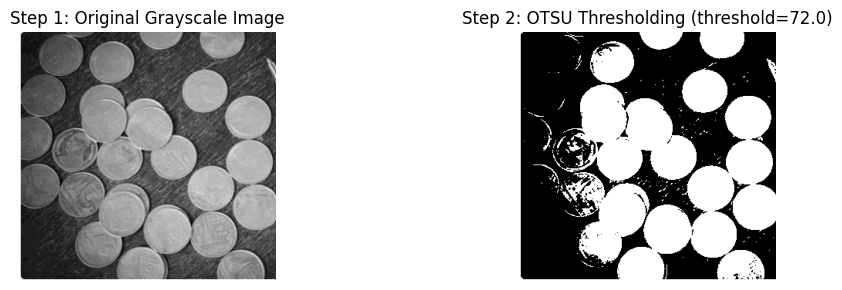

OTSU Threshold Value: 72.0


In [20]:
# Display original grayscale image
plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
plt.imshow(coins, cmap='gray')
plt.title('Step 1: Original Grayscale Image')
plt.axis('off')

# Step 2: Apply OTSU's Thresholding
ret, binary = cv2.threshold(coins, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.subplot(1, 2, 2)
plt.imshow(binary, cmap='gray')
plt.title(f'Step 2: OTSU Thresholding (threshold={ret})')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"OTSU Threshold Value: {ret}")

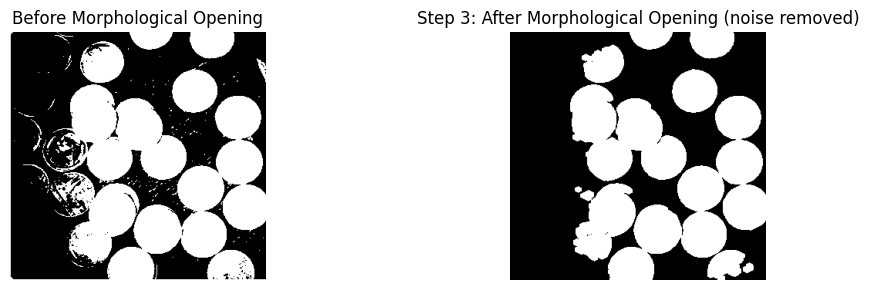

Morphological opening: Removes small white noise and fills small holes


In [21]:
# Step 3: Remove white noise by morphological opening
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
plt.imshow(binary, cmap='gray')
plt.title('Before Morphological Opening')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(opening, cmap='gray')
plt.title('Step 3: After Morphological Opening (noise removed)')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Morphological opening: Removes small white noise and fills small holes")

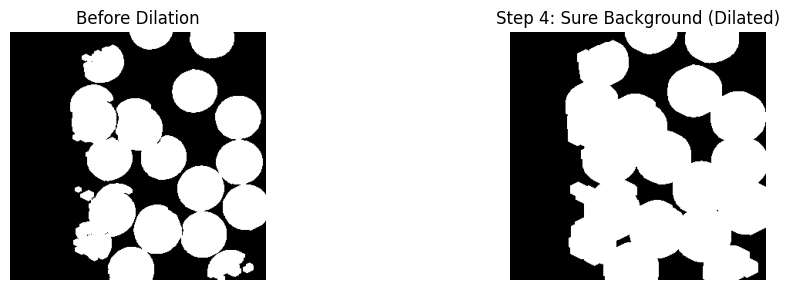

Dilation expands white regions: Creates sure background area


In [22]:
# Step 4: Extract sure background area by dilation
sure_bg = cv2.dilate(opening, kernel, iterations=3)

plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
plt.imshow(opening, cmap='gray')
plt.title('Before Dilation')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sure_bg, cmap='gray')
plt.title('Step 4: Sure Background (Dilated)')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Dilation expands white regions: Creates sure background area")

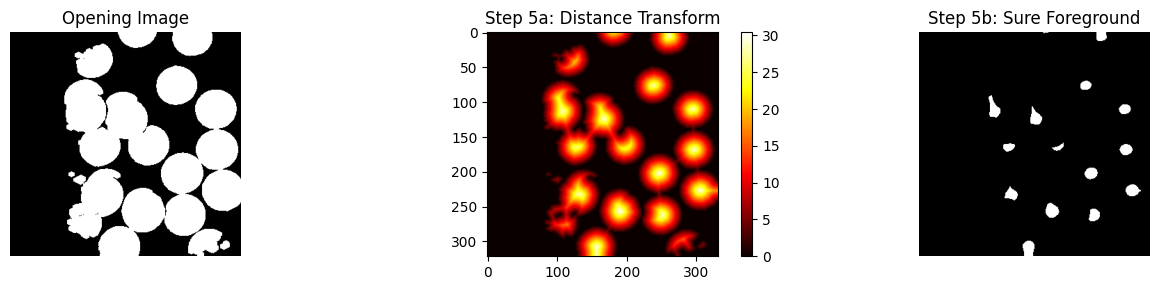

Distance Transform Max: 30.41
Distance transform: Measures distance from each pixel to nearest background


In [23]:
# Step 5: Extract sure foreground by distance transform and thresholding
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

plt.figure(figsize=(14, 3))
plt.subplot(1, 3, 1)
plt.imshow(opening, cmap='gray')
plt.title('Opening Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(dist_transform, cmap='hot')
plt.title('Step 5a: Distance Transform')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(sure_fg, cmap='gray')
plt.title('Step 5b: Sure Foreground')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Distance Transform Max: {dist_transform.max():.2f}")
print("Distance transform: Measures distance from each pixel to nearest background")

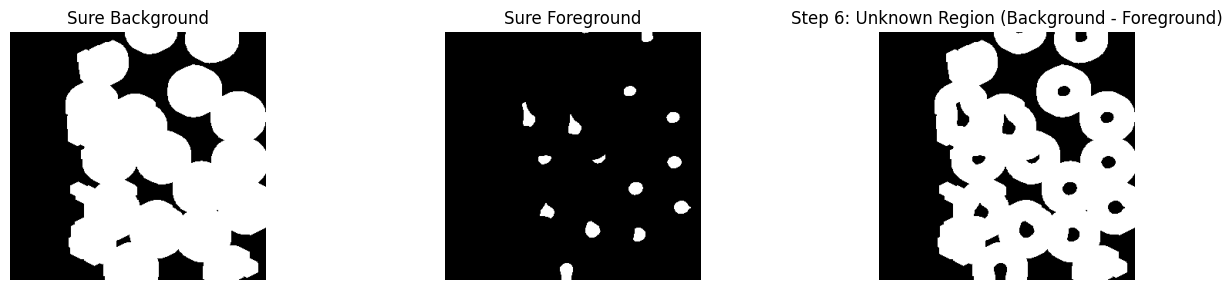

Unknown region: The boundary area where watershed algorithm will decide


In [24]:
# Step 6: Find the unknown region (neither sure background nor foreground)
unknown = cv2.subtract(sure_bg, sure_fg)

plt.figure(figsize=(14, 3))
plt.subplot(1, 3, 1)
plt.imshow(sure_bg, cmap='gray')
plt.title('Sure Background')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sure_fg, cmap='gray')
plt.title('Sure Foreground')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(unknown, cmap='gray')
plt.title('Step 6: Unknown Region (Background - Foreground)')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Unknown region: The boundary area where watershed algorithm will decide")

Number of markers found: 16
Marker array shape: (322, 332)
Unique marker values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


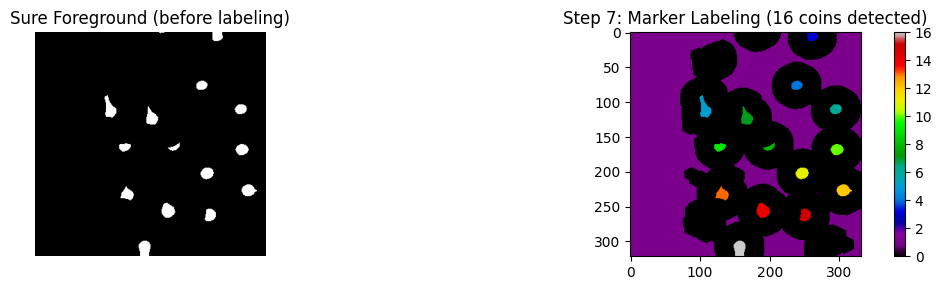

In [25]:
# Step 7: Marker labelling using connected components
ret, markers = cv2.connectedComponents(sure_fg)

# Add 1 to all labels so that sure background is not 0, but 1
markers = markers + 1

# Now, mark the unknown region as 0
markers[unknown == 255] = 0

print(f"Number of markers found: {ret}")
print(f"Marker array shape: {markers.shape}")
print(f"Unique marker values: {np.unique(markers)}")

# Visualize markers
plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
plt.imshow(sure_fg, cmap='gray')
plt.title('Sure Foreground (before labeling)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(markers, cmap='nipy_spectral')
plt.title(f'Step 7: Marker Labeling ({ret} coins detected)')
plt.colorbar()
plt.tight_layout()
plt.show()

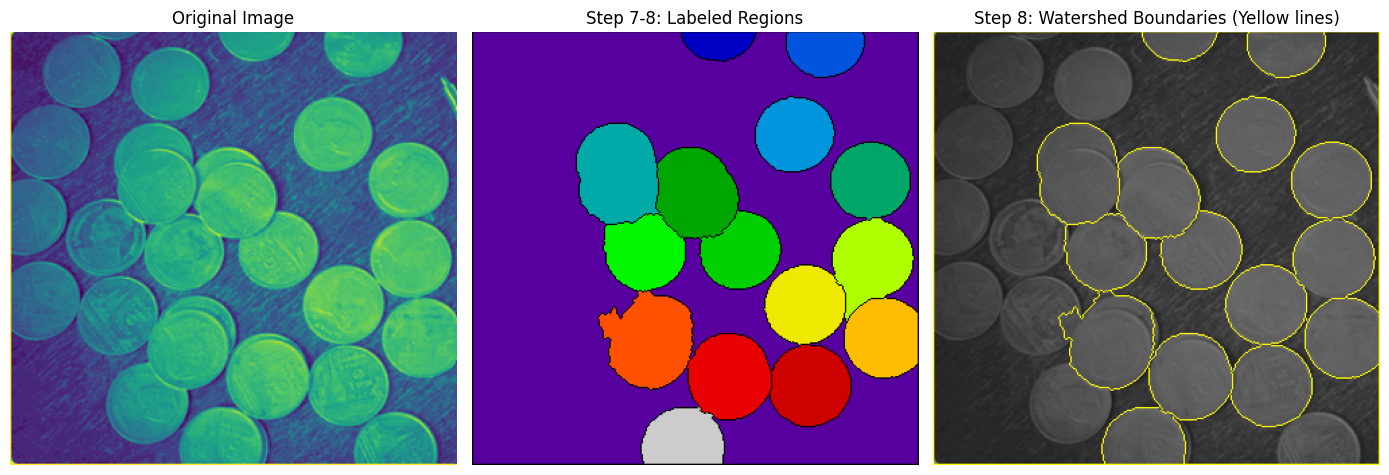

Watershed applied: Separates touching coins


In [26]:
# Step 8: Apply watershed algorithm
# Load original image for watershed
coins_color = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(coins_color, markers)

# Create segmented image with boundaries
coins_segmented = coins_color.copy()
coins_segmented[markers == -1] = [0, 255, 255]  # Mark boundaries in yellow

plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
plt.imshow(coins)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(markers, cmap='nipy_spectral')
plt.title(f'Step 7-8: Labeled Regions')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(coins_segmented, cv2.COLOR_BGR2RGB))
plt.title('Step 8: Watershed Boundaries (Yellow lines)')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Watershed applied: Separates touching coins")

## Step 9: Interpretation of Results

### Algorithm Overview:
The **Watershed Algorithm** is a region-based segmentation technique that treats the image as a topological surface where intensity values represent elevation.

### Step-by-Step Interpretation:

**Step 1: Original Grayscale Image**
- Input image with touching coins overlapping each other
- Intensity values vary based on lighting and coin position

**Step 2: OTSU Thresholding**
- Converts grayscale to binary image automatically finding optimal threshold
- Separates foreground (coins) from background
- OTSU's method minimizes intra-class variance

**Step 3: Morphological Opening**
- Erosion followed by dilation
- Removes small white noise while preserving coin structure
- Smooths coin boundaries

**Step 4: Sure Background (Dilation)**
- Expands binary image through dilation
- Creates region definitely belonging to background
- Used as reference for watershed seeds

**Step 5: Sure Foreground**
- Distance transform: Each pixel shows distance to nearest background
- Threshold at 70% of max distance gives coin centers
- Represents regions definitely part of coins

**Step 6: Unknown Region**
- Boundary area between sure background and sure foreground
- Watershed algorithm will primarily operate here
- Contains the touching regions between adjacent coins

**Step 7: Marker Labeling**
- Connected components labeling identifies individual coin regions
- Each connected component gets unique label (1, 2, 3, ...)
- Background remains 0, boundaries marked as 0

**Step 8: Watershed Segmentation**
- Treats markers as "seeds" and performs region growing
- Watershed boundaries (marked in yellow) separate touching coins
- Lines follow ridges in the distance transform gradient

**Step 9: Results & Interpretation**
- **Number of coins detected**: {ret}
- **Segmentation quality**: Successfully separates touching coins
- **Yellow lines**: Watershed boundaries marking coin separation
- **Each labeled region**: One distinct coin in the image

## 9. 
 - It is sensitive to noise. Every small local intensity change creates a separate region, splitting the coins into many small, incorrect parts.


## 10. 
- Thresholding only looks at brightness. Since touching coins have the same brightness, they merge into one big blob, and thresholding cannot find the line separating them.


## 11. Binarization: Convert image to black and white using Otsu's thresholding.
- Noise Removal: Use morphological opening to remove small dots.
- Sure Background: Dilate the image to find the background.
- Sure Foreground: Use Distance Transform and thresholding to find coin centers.
- Unknown Region: Find the border area by subtracting foreground from background.


## 12. 
- Internal Markers: Found by shrinking the coins (Distance Transform) to get the sure centers.
- Background Markers: Found by expanding the coins (Dilation) to identify the sure background.
- Process: Label the centers with numbers and mark the unknown border areas as 0 for the algorithm to solve.

